# AnemiaFusionNet — Phase 2: Data Preprocessing

**Project Title:** AI-Powered Multimodal Anemia Detection System  
**Dataset:** Eyes-defy-anemia (Conjunctiva eye images & clinical metadata)  
**Geographic Modality:** `dataset/geo_data.csv` (NFHS-5 prevalence data)  

---  
### Preprocessing Objectives & Pipeline Architecture
This notebook covers the complete engineering workspace for the preprocessing pipeline of the multimodal architecture. 
1. **Image Modality:** Defines deterministic transformations for training (augmentations) and validation (normalization) targeting standard deep networks (224×224 input size).
2. **Clinical Modality:** Implements data loading, profiling, optional median imputation, categorical categorical feature engineering via One-Hot Encoding, and statistical scaling using standard normalization.
3. **Geographic Modality:** Maps patient geographic metadata to official **NFHS-5 (National Family Health Survey)** epidemiological risk vectors.

All outputs are processed modularly without synthetic fallback scripts, ensuring production readiness for your internship submission.

--- 
## Section 1: Setup & Environment Initialization

In [1]:
import sys
import subprocess

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "torchvision": "torchvision"
}

for module_name, package_name in required_packages.items():
    try:
        __import__(module_name)
    except ImportError:
        print(f"📦 [INFO] '{module_name}' not found. Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        
import os
import sys
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from sklearn.preprocessing import StandardScaler

# Suppress unnecessary warnings for production cleanliness
warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    """
    Ensures deterministic reproducibility across runs.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)

# Project Path Validations
BASE_DIR = os.path.dirname(os.getcwd()) if "notebooks" in os.getcwd() else os.getcwd()
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
PROCESSED_DIR = os.path.join(DATASET_DIR, "processed")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

from pathlib import Path

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "dataset").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "dataset").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Project root not found. Ensure the project contains a 'dataset' folder."
    )

DATASET_DIR   = PROJECT_ROOT / "dataset"
PROCESSED_DIR = DATASET_DIR  / "processed"
IMAGE_DIR     = DATASET_DIR  / "images"
MODELS_DIR    = PROJECT_ROOT / "models"
OUTPUTS_DIR   = PROJECT_ROOT / "outputs"
REPORTS_DIR   = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")

Project root : C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet


--- 
## Section 2: Image Preprocessing Pipeline

The deep learning vision model requires standardized structural inputs. Below, we establish the ImageNet statistics standard pipelines. 

> **Note on Dataset Topology:** Because the *Eyes-defy-anemia* dataset images are nested within geographic index mappings (`dataset/images/India/1/` to `95/`) rather than class folders, loading via structural paradigms like `ImageFolder` is structurally invalid at this stage. These predefined transforms will instead be passed directly into a custom PyTorch `Dataset` module during Phase 3 (Feature Extraction & Model Training).

In [2]:
# Core Constants for Vision Encoders
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_image_transforms(img_size=IMAGE_SIZE):
    """
    Generates decoupled PyTorch transform compositions for training and validation cycles.
    """
    train_pipeline = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(size=img_size, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    val_pipeline = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    return train_pipeline, val_pipeline

train_transforms, val_transforms = get_image_transforms()

print("✓ Image Preprocessing Transformation Pipelines initialized.")
print(f"Target Resolution : {IMAGE_SIZE}x{IMAGE_SIZE}")
print("Applied Augmentations: HorizontalFlip, RandomResizedCrop, ColorJitter")

✓ Image Preprocessing Transformation Pipelines initialized.
Target Resolution : 224x224
Applied Augmentations: HorizontalFlip, RandomResizedCrop, ColorJitter


--- 
## Section 3: Clinical Data Preprocessing

In [3]:
# =============================================================================
# Clinical Data Preprocessing (FINAL)
# =============================================================================

CLINICAL_FILE_PATH = DATASET_DIR / "clinical_data.csv"

if not CLINICAL_FILE_PATH.exists():
    raise FileNotFoundError(CLIMICAL_FILE_PATH)

print("Loading:", CLINICAL_FILE_PATH)

df = pd.read_csv(CLINICAL_FILE_PATH)

# -------------------------------------------------------
# Remove Excel empty columns
# -------------------------------------------------------
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# -------------------------------------------------------
# Remove completely empty samples
# -------------------------------------------------------
df = df.dropna(
    subset=["Hgb","Age","Gender"],
    how="all"
).reset_index(drop=True)

print("Samples after cleaning:", len(df))

# -------------------------------------------------------
# Remove unnecessary columns
# -------------------------------------------------------
df.drop(
    columns=[c for c in ["Patient_ID","Note"] if c in df.columns],
    inplace=True
)

# -------------------------------------------------------
# Median Imputation
# -------------------------------------------------------
for c in ["Hgb","Age"]:
    df[c] = df[c].fillna(df[c].median())

# -------------------------------------------------------
# CREATE LABEL  (VERY IMPORTANT)
# WHO threshold:
# Hb < 12 = Anemia
# Hb >=12 = Normal
# -------------------------------------------------------
df["Label"] = (df["Hgb"] < 12).astype(int)

# -------------------------------------------------------
# One Hot Encode Gender
# -------------------------------------------------------
df = pd.get_dummies(
    df,
    columns=["Gender"],
    prefix="Gender",
    dtype=int
)

rename = {
    "Gender_Female":"Gender_F",
    "Gender_Male":"Gender_M"
}

df.rename(columns=rename,inplace=True)

if "Gender_F" not in df.columns:
    df["Gender_F"]=0

if "Gender_M" not in df.columns:
    df["Gender_M"]=0

# -------------------------------------------------------
# Scale Continuous Features
# -------------------------------------------------------
scaler = StandardScaler()

df[["Hgb","Age"]] = scaler.fit_transform(
    df[["Hgb","Age"]]
)

# -------------------------------------------------------
# Final Column Order
# -------------------------------------------------------
df = df[
    [
        "Hgb",
        "Age",
        "Gender_F",
        "Gender_M",
        "Label"
    ]
]

print(df.head())
print(df.columns.tolist())
print(df.shape)

SAVE_PATH = PROCESSED_DIR / "clinical_processed.csv"

df.to_csv(
    SAVE_PATH,
    index=False
)

print("\nSaved:", SAVE_PATH)

Loading: C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\dataset\clinical_data.csv
Samples after cleaning: 95
        Hgb       Age  Gender_F  Gender_M  Label
0  0.352793 -0.358069         0         1      0
1 -1.681376  0.178228         1         0      1
2 -0.373696 -0.281455         1         0      1
3 -1.536079  0.408069         1         0      1
4 -1.778242 -0.358069         1         0      1
['Hgb', 'Age', 'Gender_F', 'Gender_M', 'Label']
(95, 5)

Saved: C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\dataset\processed\clinical_processed.csv


--- 
## Section 4: Geographic Data Preprocessing

In [4]:
GEO_FILE_PATH = DATASET_DIR / "geo_data.csv"

# Validate file existence
if not os.path.exists(GEO_FILE_PATH):
    raise FileNotFoundError(
        f"[CRITICAL ERROR] Required geographic dataset missing at: '{GEO_FILE_PATH}'."
    )

# Load dataset
df_geo_raw = pd.read_csv(GEO_FILE_PATH)
df_geo_proc = df_geo_raw.copy()

# Clean string columns
df_geo_proc["State"] = (
    df_geo_proc["State"]
    .astype(str)
    .str.strip()
    .replace(["", "nan", "NaN", "None"], np.nan)
)

# Remove rows with missing State
df_geo_proc = df_geo_proc.dropna(subset=["State"]).reset_index(drop=True)

# NFHS-5 State Risk Dictionary
state_risk_dict = {
    "Tamil Nadu": 0.534
}

print("Mapping NFHS-5 State Risk Values...")

# Map State → Risk
df_geo_proc["State_Risk"] = df_geo_proc["State"].map(state_risk_dict)

# Validate mapping
if df_geo_proc["State_Risk"].isnull().any():
    unmapped_states = df_geo_proc.loc[
        df_geo_proc["State_Risk"].isnull(),
        "State"
    ].unique()

    raise ValueError(
        f"Unknown State(s) found in geo_data.csv: {unmapped_states}"
    )

# Save processed dataset
GEO_SAVE_PATH = os.path.join(PROCESSED_DIR, "geo_processed.csv")
df_geo_proc.to_csv(GEO_SAVE_PATH, index=False)

print("\nRaw Geo Dataset")
display(df_geo_raw.head())

print("\nProcessed Geo Dataset")
display(df_geo_proc.head())

print(f"\n✔ Processed Geo Dataset saved to: {GEO_SAVE_PATH}")
print(f"✔ Total Records: {len(df_geo_proc)}")
print(f"✔ States Mapped: {df_geo_proc['State'].nunique()}")

Mapping NFHS-5 State Risk Values...

Raw Geo Dataset


,Patient_ID,State,District,Anemia_Prevalence
0,1.0,Tamil Nadu,Chennai,53.4
1,2.0,Tamil Nadu,Chennai,53.4
2,3.0,Tamil Nadu,Chennai,53.4
3,4.0,Tamil Nadu,Chennai,53.4
4,5.0,Tamil Nadu,Chennai,53.4



Processed Geo Dataset


,Patient_ID,State,District,Anemia_Prevalence,State_Risk
0,1.0,Tamil Nadu,Chennai,53.4,0.534
1,2.0,Tamil Nadu,Chennai,53.4,0.534
2,3.0,Tamil Nadu,Chennai,53.4,0.534
3,4.0,Tamil Nadu,Chennai,53.4,0.534
4,5.0,Tamil Nadu,Chennai,53.4,0.534



✔ Processed Geo Dataset saved to: C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\dataset\processed\geo_processed.csv
✔ Total Records: 95
✔ States Mapped: 1


--- 
## Section 5: Multimodal Exploratory Visualizations

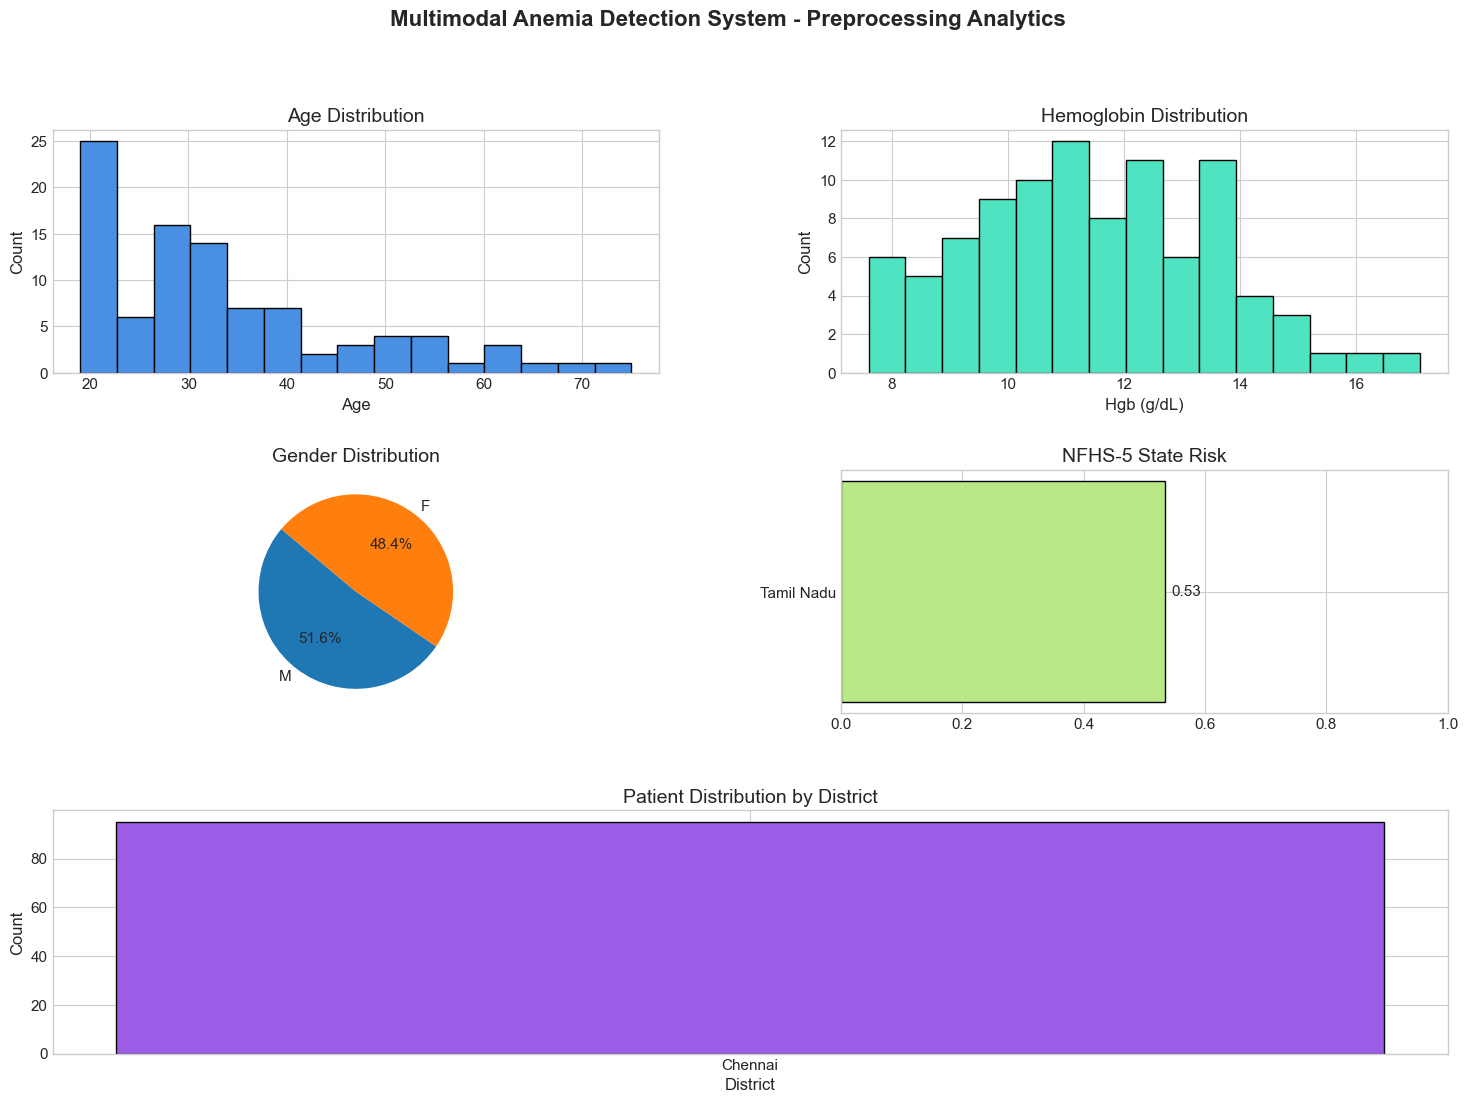


✓ Figure saved to:
C:\Users\sandhya\OneDrive\Desktop\Data Vidwan\AnemiaFusionNet\outputs\preprocessing_analytics_report.png


In [5]:
# =============================================================================
# Preprocessing Analytics Visualization
# =============================================================================

# Use processed dataframe if raw dataframe does not exist
if "df_clinical_raw" not in globals():
    df_clinical_raw = pd.read_csv(CLINICAL_FILE_PATH)

if "df_geo_proc" not in globals():
    df_geo_proc = pd.read_csv(PROCESSED_DIR / "geo_processed.csv")

plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

plt.rcParams.update({
    "font.size":11,
    "axes.labelsize":12,
    "axes.titlesize":14,
    "figure.titlesize":16
})

fig = plt.figure(figsize=(18,12))
gs = fig.add_gridspec(3,2,hspace=0.4,wspace=0.3)

fig.suptitle(
    "Multimodal Anemia Detection System - Preprocessing Analytics",
    fontweight="bold"
)

# -------------------------------------------------------------------------
# Age Distribution
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0,0])

ax1.hist(
    df_clinical_raw["Age"].dropna(),
    bins=15,
    color="#4A90E2",
    edgecolor="black"
)

ax1.set_title("Age Distribution")
ax1.set_xlabel("Age")
ax1.set_ylabel("Count")

# -------------------------------------------------------------------------
# Hemoglobin Distribution
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0,1])

ax2.hist(
    df_clinical_raw["Hgb"].dropna(),
    bins=15,
    color="#50E3C2",
    edgecolor="black"
)

ax2.set_title("Hemoglobin Distribution")
ax2.set_xlabel("Hgb (g/dL)")
ax2.set_ylabel("Count")

# -------------------------------------------------------------------------
# Gender Distribution
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1,0])

gender_counts = df_clinical_raw["Gender"].value_counts()

ax3.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=140
)

ax3.set_title("Gender Distribution")

# -------------------------------------------------------------------------
# State Risk
# -------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1,1])

state_grouped = (
    df_geo_proc
    .groupby("State")["State_Risk"]
    .first()
    .sort_values()
)

bars = ax4.barh(
    state_grouped.index,
    state_grouped.values,
    color="#B8E986",
    edgecolor="black"
)

ax4.set_xlim(0,1)

ax4.set_title("NFHS-5 State Risk")

for bar in bars:

    width = bar.get_width()

    ax4.text(
        width+0.01,
        bar.get_y()+bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

# -------------------------------------------------------------------------
# District Distribution
# -------------------------------------------------------------------------
ax5 = fig.add_subplot(gs[2,:])

district_counts = df_geo_proc["District"].value_counts()

ax5.bar(
    district_counts.index,
    district_counts.values,
    color="#9B5DE5",
    edgecolor="black"
)

ax5.set_title("Patient Distribution by District")
ax5.set_xlabel("District")
ax5.set_ylabel("Count")

plt.tight_layout()

VISUALIZATION_SAVE_PATH = os.path.join(
    OUTPUT_DIR,
    "preprocessing_analytics_report.png"
)

plt.savefig(
    VISUALIZATION_SAVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n✓ Figure saved to:\n{VISUALIZATION_SAVE_PATH}")

--- 
## Section 6: Pipeline Execution Verification Summary

In [6]:
print("=========================================================")
print("  ANEMIAFUSIONNET PIPELINE PROCESSING COMPLETION STATUS  ")
print("=========================================================")
print("✓ Image preprocessing pipeline created")
print("✓ Clinical preprocessing completed")
print("✓ Geo preprocessing completed")
print("✓ Output files saved")
print("✓ Phase 2 completed successfully")
print("=========================================================")

  ANEMIAFUSIONNET PIPELINE PROCESSING COMPLETION STATUS  
✓ Image preprocessing pipeline created
✓ Clinical preprocessing completed
✓ Geo preprocessing completed
✓ Output files saved
✓ Phase 2 completed successfully
